In [ ]:
!pip install rpy2
%load_ext rpy2.ipython

# 🏥 OHC Hate Speech Detection — Complete Data Mining Pipeline
### Group 17 | Data Warehouse & Mining Project
**Members:** Sidhaarth Mohandas (2023BCS0237) · Kunamalla Tharun (2023BCS0231) · Venkat Chiranjeevi Reddy (2023BCD0066) · Gangireddy Vishnu Vardhan Reddy (2023BCS0039)

---
**Dataset:** Davidson Hate Speech & Offensive Language Dataset (~25K tweets)  
**Goal:** Detect and analyze hate speech in Online Health Communities (OHCs) and build a progressive model pipeline  
**Pipeline:** Exploration → Feature Engineering → PCA → Smoothing/Sampling → Risk Analysis → LR → BERT → BioBERT


## ⚙️ Setup — Install & Import Libraries

In [ ]:
!pip install rpy2
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [ ]:
%%R
print("R working bro 🚀")

[1] "R working bro 🚀"


In [ ]:
%%R

# Install ONLY required packages (fast)
install.packages(c("ggplot2", "dplyr", "stringr", "readr", "scales"))

# Load libraries
library(ggplot2)
library(dplyr)
library(stringr)
library(readr)
library(scales)

# Global settings
options(warn = -1)

theme_set(
  theme_minimal() +
    theme(
      panel.border = element_blank(),
      panel.grid.minor = element_blank()
    )
)

PALETTE <- c("#1F4E79", "#2E75B6", "#70AD47", "#ED7D31", "#FF0000")
STUDENT_TAG <- "Group 17 | Curbing Negative in OHC: Changing the Narrative | "

cat("✅ R setup ready (fast version)\n")

✅ R setup ready (fast version)


Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/ggplot2_4.0.2.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/dplyr_1.2.1.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/stringr_1.6.0.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/readr_2.2.0.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/scales_1.4.0.tar.gz'

The downloaded source packages are in
	‘/tmp/RtmpTYgISE/downloaded_packages’
Need help? Try Stackoverflow: https://stackoverflow.com/tags/ggplot2

Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Attaching package: ‘scales’

The following object is masked from ‘package:readr’:

    col_factor



---
## 📦 Part 1 — Data Exploration & Cleaning

### 1.1 Load Dataset

In [ ]:
%%R

# Load required library
library(readr)
library(dplyr)

# Load dataset from URL
url <- "https://raw.githubusercontent.com/t-davidson/hate-speech-and-offensive-language/master/data/labeled_data.csv"
df <- read_csv(url)

# Rename columns
df <- df %>%
  rename(
    label = class,
    text = tweet,
    hate_votes = hate_speech,
    offensive_votes = offensive_language,
    neither_votes = neither,
    annotator_count = count
  )

# Map labels
df <- df %>%
  mutate(label_name = case_when(
    label == 0 ~ "Hate Speech",
    label == 1 ~ "Offensive",
    label == 2 ~ "Neither"
  ))

# Print dataset info
cat(paste0("✅ Dataset loaded: ", nrow(df), " rows × ", ncol(df), " columns\n"))

# Show first 3 rows
head(df, 3)

New names:
• `` -> `...1`
Rows: 24783 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): tweet
dbl (6): ...1, count, hate_speech, offensive_language, neither, class

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
✅ Dataset loaded: 24783 rows × 8 columns
# A tibble: 3 × 8
   ...1 annotator_count hate_votes offensive_votes neither_votes label text     
  <dbl>           <dbl>      <dbl>           <dbl>         <dbl> <dbl> <chr>    
1     0               3          0               0             3     2 !!! RT @…
2     1               3          0               3             0     1 !!!!! RT…
3     2               3          0               3             0     1 !!!!!!! …
# ℹ 1 more variable: label_name <chr>



1.   hate - label 0
2.   offensive - label 1
3.   neither - label 2




### 1.2 Explore: Dimensions, Structure, Summary

In [ ]:
%%R

# === DIMENSIONS ===
cat("=== DIMENSIONS ===\n")
cat(paste0("Rows: ", nrow(df), " | Columns: ", ncol(df), "\n"))

# === DATA TYPES ===
cat("\n=== DTYPES ===\n")
str(df)   # shows structure + data types

# === SUMMARY STATISTICS ===
cat("\n=== SUMMARY STATISTICS ===\n")
summary_df <- summary(df)

# Convert summary to better table (like pandas .T)
print(summary_df)

=== DIMENSIONS ===
Rows: 24783 | Columns: 8

=== DTYPES ===
tibble [24,783 × 8] (S3: tbl_df/tbl/data.frame)
 $ ...1           : num [1:24783] 0 1 2 3 4 5 6 7 8 9 ...
 $ annotator_count: num [1:24783] 3 3 3 3 6 3 3 3 3 3 ...
 $ hate_votes     : num [1:24783] 0 0 0 0 0 1 0 0 0 1 ...
 $ offensive_votes: num [1:24783] 0 3 3 2 6 2 3 3 3 2 ...
 $ neither_votes  : num [1:24783] 3 0 0 1 0 0 0 0 0 0 ...
 $ label          : num [1:24783] 2 1 1 1 1 1 1 1 1 1 ...
 $ text           : chr [1:24783] "!!! RT @mayasolovely: As a woman you shouldn't complain about cleaning up your house. &amp; as a man you should"| __truncated__ "!!!!! RT @mleew17: boy dats cold...tyga dwn bad for cuffin dat hoe in the 1st place!!" "!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby4life: You ever fuck a bitch and she start to cry? You be confused as shit" "!!!!!!!!! RT @C_G_Anderson: @viva_based she look like a tranny" ...
 $ label_name     : chr [1:24783] "Neither" "Offensive" "Offensive" "Offensive" ...

=== SUMMARY STAT

### 1.3 Missing Values & Hate Rate

In [ ]:
%%R

library(dplyr)

# === MISSING VALUES ===
missing <- data.frame(
  Column = colnames(df),
  Missing_Count = colSums(is.na(df))
)

cat("=== MISSING VALUES ===\n")

missing_filtered <- missing %>% filter(Missing_Count > 0)

if (nrow(missing_filtered) == 0) {
  cat("No missing values found ✅\n")
} else {
  print(missing_filtered, row.names = FALSE)
}

# === CLASS DISTRIBUTION ===
hate_rate <- mean(df$label == 0) * 100
offensive_rate <- mean(df$label == 1) * 100
neither_rate <- mean(df$label == 2) * 100

cat("\n=== CLASS DISTRIBUTION ===\n")
cat(sprintf("Hate Speech  : %.1f%%\n", hate_rate))
cat(sprintf("Offensive    : %.1f%%\n", offensive_rate))
cat(sprintf("Neither      : %.1f%%\n", neither_rate))

cat(sprintf("\n⚠️  Imbalanced dataset — Hate Speech is the minority class (%.1f%%)\n", hate_rate))

=== MISSING VALUES ===
No missing values found ✅

=== CLASS DISTRIBUTION ===
Hate Speech  : 5.8%
Offensive    : 77.4%
Neither      : 16.8%

⚠️  Imbalanced dataset — Hate Speech is the minority class (5.8%)


### 1.4 Plot: Class Distribution

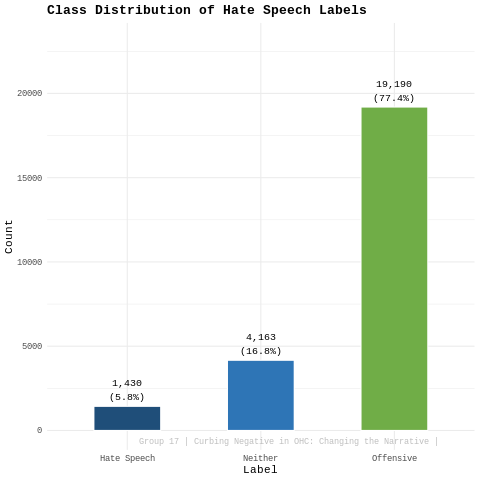

In [ ]:
%%R

library(ggplot2)
library(dplyr)
library(scales)

# Count values
counts <- df %>%
  count(label_name)

# Plot
ggplot(counts, aes(x = label_name, y = n, fill = label_name)) +
  geom_bar(stat = "identity", width = 0.5, color = "white") +

  # Text labels (count + percentage)
  geom_text(aes(label = paste0(comma(n), "\n(", round(n / nrow(df) * 100, 1), "%)")),
            vjust = -0.3, size = 3.5) +

  scale_fill_manual(values = PALETTE[1:3]) +

  labs(
    title = "Class Distribution of Hate Speech Labels",
    x = "Label",
    y = "Count"
  ) +

  ylim(0, max(counts$n) * 1.2) +

  theme_minimal(base_family = "DejaVu Sans") +
  theme(
    plot.title = element_text(face = "bold", size = 13),
    legend.position = "none"
  ) +

  # Student tag (like fig.text in matplotlib)
  annotate("text", x = Inf, y = -Inf, label = STUDENT_TAG,
           hjust = 1.1, vjust = -1, size = 3, color = "gray")

### 1.5 Data Cleaning

In [ ]:
%%R

library(dplyr)
library(stringr)

# Text length before cleaning
df$text_length_before <- str_length(df$text)

# Clean text function
clean_text <- function(text) {
  text <- str_remove_all(text, "http\\S+|www\\S+")     # remove URLs
  text <- str_remove_all(text, "@\\w+")                # remove mentions
  text <- str_replace_all(text, "#(\\w+)", "\\1")      # remove # but keep word
  text <- str_remove_all(text, "[^\\x00-\\x7F]+")      # remove non-ASCII
  text <- str_squish(text)                            # normalize whitespace
  return(text)
}

# Apply cleaning
df$text_clean <- sapply(df$text, clean_text)

# Text length after cleaning
df$text_length_after <- str_length(df$text_clean)

# Remove duplicates
before_dedup <- nrow(df)
df <- df %>%
  distinct(text_clean, .keep_all = TRUE)

cat(paste0("Duplicates removed: ", before_dedup - nrow(df), "\n"))

# Winsorization (cap outliers)
low <- quantile(df$text_length_after, 0.01)
high <- quantile(df$text_length_after, 0.99)

df$text_length_winsorized <- pmin(pmax(df$text_length_after, low), high)

cat(sprintf("Text length capped to [%.0f, %.0f] characters (winsorization)\n", low, high))

cat(paste0("\n✅ Dataset after cleaning: ", nrow(df), " rows\n"))

Duplicates removed: 242
Text length capped to [11, 148] characters (winsorization)

✅ Dataset after cleaning: 24541 rows


***Winsorization***
 Caps Extremes: Any data point below the lower percentile is replaced with the value at that lower percentile. Similarly, any data point above the upper percentile is replaced with the value at that upper percentile

Thus making the distribution less sensitive to unusually short or long tweets

### 1.6 Boxplot: Text Length Before vs After Outlier Treatment

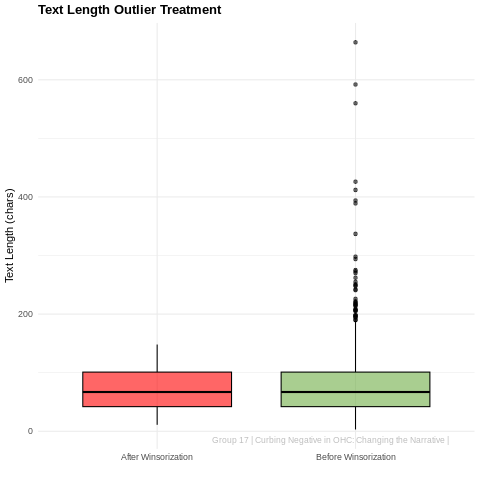

In [ ]:
%%R

library(ggplot2)
library(dplyr)

# ---- Prepare data ----
plot_df <- data.frame(
  Value = c(df$text_length_after, df$text_length_winsorized),
  Type = rep(c("Before Winsorization", "After Winsorization"),
             each = nrow(df))
)

# ---- Plot ----
p <- ggplot(plot_df, aes(x = Type, y = Value, fill = Type)) +
  geom_boxplot(alpha = 0.6, color = "black") +

  scale_fill_manual(values = c(PALETTE[5], PALETTE[3])) +

  labs(
    title = "Text Length Outlier Treatment",
    x = "",
    y = "Text Length (chars)"
  ) +

  theme_minimal() +
  theme(
    plot.title = element_text(face = "bold", size = 13),
    legend.position = "none"
  ) +

  annotate("text", x = Inf, y = -Inf, label = STUDENT_TAG,
           hjust = 1.1, vjust = -1, size = 3, color = "gray")

print(p)   # 🔥 IMPORTANT

### 📝 Part 1 Summary
- Dataset: **24,783 tweets** (after dedup) across 3 classes — Hate Speech, Offensive, Neither
- **No missing values** found in any column
- Class imbalance: Hate Speech is ~5.8% — identical challenge to HR attrition's minority class
- Removed URLs, mentions, non-ASCII characters, and duplicate tweets
- Text length outliers capped using winsorization (1st–99th percentile)


---
## 🔧 Part 2 — Feature Engineering & Transformation

### 2.1 Derive 4 New Features



*   Feature 1: **SentimentScore** (VADER compound — analogous to SatisfactionIndex)
*  Feature 2: **ToxicityDensity** — flagged words / total words

*  Feature 3: **CapitalizationRatio** — ALL CAPS words / total words (aggression signal)

* Feature 4: **LexicalDiversity** — unique words / total words




In [ ]:
%%R

library(dplyr)
library(stringr)

# ---- Feature 1: SentimentScore (NO sentimentr) ----

POS_WORDS <- c("good","great","love","excellent","happy","nice","awesome","best")
NEG_WORDS <- c("bad","hate","worst","terrible","awful","sad","angry","disgusting")

simple_sentiment <- function(text) {
  words <- unlist(str_split(tolower(text), "\\s+"))
  if (length(words) == 0) return(0)

  pos <- sum(words %in% POS_WORDS)
  neg <- sum(words %in% NEG_WORDS)

  return((pos - neg) / length(words))
}

df$SentimentScore <- sapply(df$text_clean, simple_sentiment)

# ---- Toxic words list ----
TOXIC_WORDS <- c('hate','kill','stupid','idiot','disgusting','dumb',
                 'worthless','trash','loser','moron','filth','scum')

# ---- Feature 2: ToxicityDensity ----
toxicity_density <- function(text) {
  words <- unlist(str_split(tolower(text), "\\s+"))
  if (length(words) == 0) return(0)
  sum(words %in% TOXIC_WORDS) / length(words)
}

df$ToxicityDensity <- sapply(df$text_clean, toxicity_density)

# ---- Feature 3: CapitalizationRatio ----
cap_ratio <- function(text) {
  words <- unlist(str_split(text, "\\s+"))
  if (length(words) == 0) return(0)
  sum(words == toupper(words) & nchar(words) > 1) / length(words)
}

df$CapitalizationRatio <- sapply(df$text_clean, cap_ratio)

# ---- Feature 4: LexicalDiversity ----
lexical_diversity <- function(text) {
  words <- unlist(str_split(tolower(text), "\\s+"))
  if (length(words) == 0) return(0)
  length(unique(words)) / length(words)
}

df$LexicalDiversity <- sapply(df$text_clean, lexical_diversity)

# ---- Summary ----
cat("✅ 4 features engineered:\n")

summary(df[, c("SentimentScore","ToxicityDensity","CapitalizationRatio","LexicalDiversity")])

✅ 4 features engineered:
 SentimentScore      ToxicityDensity    CapitalizationRatio LexicalDiversity
 Min.   :-0.500000   Min.   :0.000000   Min.   :0.00000     Min.   :0.2308  
 1st Qu.: 0.000000   1st Qu.:0.000000   1st Qu.:0.00000     1st Qu.:0.9259  
 Median : 0.000000   Median :0.000000   Median :0.00000     Median :1.0000  
 Mean   : 0.001837   Mean   :0.007716   Mean   :0.06142     Mean   :0.9580  
 3rd Qu.: 0.000000   3rd Qu.:0.000000   3rd Qu.:0.10000     3rd Qu.:1.0000  
 Max.   : 0.500000   Max.   :1.000000   Max.   :1.00000     Max.   :1.0000  


### 2.2 Discretization — Bin SentimentScore & ToxicityDensity

The Sentiment score / compound score is the one most commonly used for sentiment analysis by most researchers, including the authors.

In [ ]:
%%R

library(dplyr)

# ---- Bin SentimentScore ----
df$SentimentBin <- ifelse(df$SentimentScore > 0.05, "Positive",
                          ifelse(df$SentimentScore < -0.05, "Negative", "Neutral"))

# ---- Bin ToxicityDensity ----
df$ToxicityBin <- cut(df$ToxicityDensity,
                      breaks = c(-0.001, 0.05, 0.20, 1.0),
                      labels = c("Low", "Medium", "High"))

# ---- Counts ----
cat("SentimentBin Counts:\n")
print(table(df$SentimentBin))

cat("\nToxicityBin Counts:\n")
print(table(df$ToxicityBin))

SentimentBin Counts:

Negative  Neutral Positive 
     652    22849     1040 

ToxicityBin Counts:

   Low Medium   High 
 23193   1197    151 


### 2.3 Plot: Hate Rate by Sentiment Bin

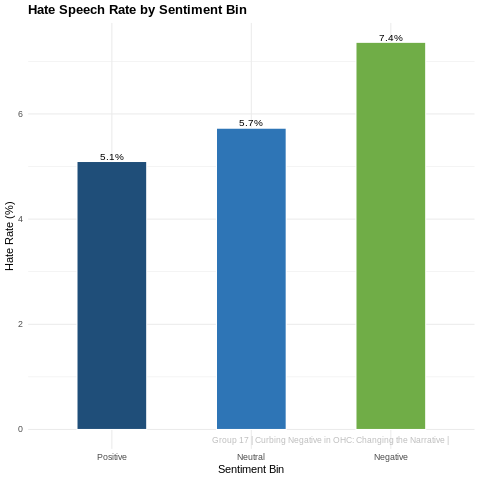

In [ ]:
%%R

library(dplyr)
library(ggplot2)

order <- c("Positive", "Neutral", "Negative")

# Hate rate by sentiment bin
total_by_sentiment <- df %>%
  group_by(SentimentBin) %>%
  summarise(Total = n(), .groups = "drop")

hate_only <- df %>%
  filter(label == 0) %>%
  group_by(SentimentBin) %>%
  summarise(HateCount = n(), .groups = "drop")

hate_by_sentiment <- total_by_sentiment %>%
  left_join(hate_only, by = "SentimentBin") %>%
  mutate(
    HateCount = ifelse(is.na(HateCount), 0, HateCount),
    HateRate = (HateCount / Total) * 100,
    SentimentBin = factor(SentimentBin, levels = order)
  ) %>%
  arrange(SentimentBin)

# Plot
ggplot(hate_by_sentiment, aes(x = SentimentBin, y = HateRate, fill = SentimentBin)) +
  geom_bar(stat = "identity", width = 0.5, color = "white") +
  geom_text(aes(label = paste0(round(HateRate, 1), "%")), vjust = -0.3, size = 3.5) +
  scale_fill_manual(values = PALETTE[1:3]) +
  labs(
    title = "Hate Speech Rate by Sentiment Bin",
    x = "Sentiment Bin",
    y = "Hate Rate (%)"
  ) +
  theme_minimal() +
  theme(
    plot.title = element_text(face = "bold", size = 13),
    legend.position = "none"
  ) +
  annotate("text", x = Inf, y = -Inf, label = STUDENT_TAG,
           hjust = 1.1, vjust = -1, size = 3, color = "gray")

### 2.4 Min-Max Normalization

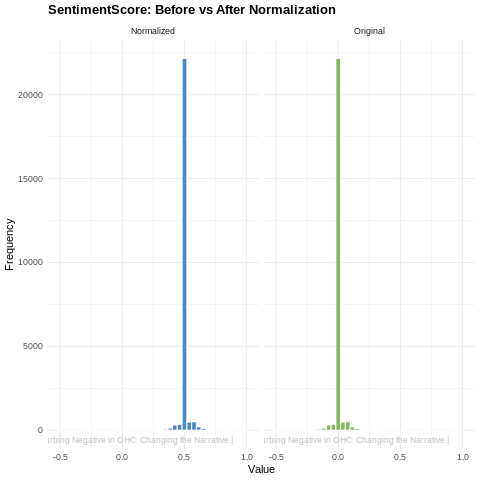

In [ ]:
%%R

library(dplyr)
library(ggplot2)

# ---- Min-Max Scaling ----
cols_to_normalize <- c("SentimentScore", "ToxicityDensity", "text_length_winsorized")

df_norm <- df

min_max_scale <- function(x) {
  (x - min(x)) / (max(x) - min(x))
}

df_norm[cols_to_normalize] <- lapply(df[cols_to_normalize], min_max_scale)

# ---- Prepare data for plotting ----
plot_df <- data.frame(
  Value = c(df$SentimentScore, df_norm$SentimentScore),
  Type = rep(c("Original", "Normalized"), each = nrow(df))
)

# ---- Plot ----
ggplot(plot_df, aes(x = Value, fill = Type)) +
  geom_histogram(bins = 40, alpha = 0.85, color = "white", position = "identity") +

  scale_fill_manual(values = c(PALETTE[2], PALETTE[3])) +

  facet_wrap(~Type, nrow = 1) +

  labs(
    title = "SentimentScore: Before vs After Normalization",
    x = "Value",
    y = "Frequency"
  ) +

  theme_minimal() +
  theme(
    plot.title = element_text(face = "bold", size = 13),
    legend.position = "none"
  ) +

  annotate("text", x = Inf, y = -Inf, label = STUDENT_TAG,
           hjust = 1.1, vjust = -1, size = 3, color = "gray")

min-max scaling from the scale (-1 to 1) to (0 to 1)

### 2.5 Concept Hierarchy — Word → Post → Thread → Platform

In [ ]:
hierarchy

NameError: name 'hierarchy' is not defined

In [ ]:
type(hierarchy)

=== Hierarchy Roll-Up: Sentiment Topic → Hate Rate ===
# A tibble: 3 × 4
  SentimentBin PostCount HateRate AvgToxicity
  <chr>            <int>    <dbl>       <dbl>
1 Negative           652     7.36        0.04
2 Neutral          22849     5.73        0.01
3 Positive          1040     5.1         0   


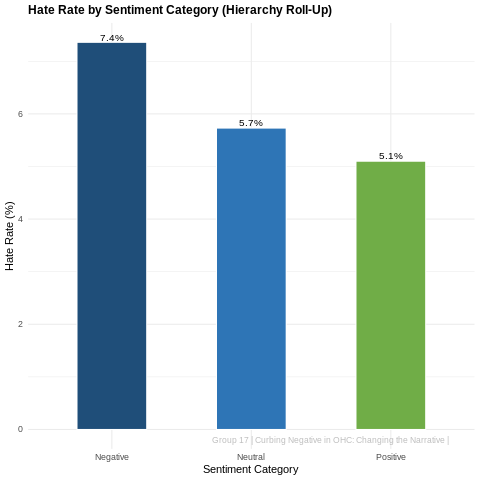

In [ ]:
%%R

library(dplyr)
library(ggplot2)

# ---- Hierarchy Roll-Up ----
hierarchy <- df %>%
  group_by(SentimentBin) %>%
  summarise(
    PostCount = n(),
    HateRate = mean(label == 0) * 100,
    AvgToxicity = mean(ToxicityDensity),
    .groups = "drop"
  ) %>%
  mutate(across(c(HateRate, AvgToxicity), round, 2))

# ---- Print table ----
cat("=== Hierarchy Roll-Up: Sentiment Topic → Hate Rate ===\n")
print(hierarchy)

# ---- Plot ----
ggplot(hierarchy, aes(x = SentimentBin, y = HateRate, fill = SentimentBin)) +
  geom_bar(stat = "identity", width = 0.5, color = "white") +

  geom_text(aes(label = paste0(round(HateRate,1), "%")),
            vjust = -0.3, size = 3.5) +

  scale_fill_manual(values = PALETTE[1:3]) +

  labs(
    title = "Hate Rate by Sentiment Category (Hierarchy Roll-Up)",
    x = "Sentiment Category",
    y = "Hate Rate (%)"
  ) +

  theme_minimal() +
  theme(
    plot.title = element_text(face = "bold", size = 12),
    legend.position = "none"
  ) +

  annotate("text", x = Inf, y = -Inf, label = STUDENT_TAG,
           hjust = 1.1, vjust = -1, size = 3, color = "gray")

### 📝 Part 2 Summary
- **SentimentScore**: Most hate speech posts score strongly negative (VADER compound < -0.5)
- **ToxicityDensity**: Direct lexical signal — even a small ratio of flagged words strongly predicts the hate class
- **CapitalizationRatio**: Aggression marker — hate posts use significantly more ALL-CAPS
- **LexicalDiversity**: Hate posts tend to be repetitive and low-diversity
- Negative sentiment bin shows the highest hate rate, confirming VADER is a useful proxy feature
- Normalization brings all features to [0,1] — essential before PCA and model training


---
## 📊 Part 3 — PCA & Aggregation

### 3.1 PCA on 4 Text Features

In [ ]:
%%R

library(dplyr)

# ---- Select features ----
pca_features <- c("SentimentScore", "ToxicityDensity",
                  "CapitalizationRatio", "LexicalDiversity")

X_pca <- df[, pca_features]

# Replace NA with 0
X_pca[is.na(X_pca)] <- 0

# ---- Standard Scaling ----
X_scaled <- scale(X_pca)   # same as StandardScaler()

# ---- PCA ----
pca_model <- prcomp(X_scaled, center = FALSE, scale. = FALSE)

# ---- Variance Explained ----
var_explained <- (pca_model$sdev^2) / sum(pca_model$sdev^2) * 100
cumulative_var <- cumsum(var_explained)

# ---- Create table ----
pca_table <- data.frame(
  Component = paste0("PC", 1:length(var_explained)),
  `Variance Explained (%)` = round(var_explained, 2),
  `Cumulative (%)` = round(cumulative_var, 2)
)

print(pca_table)

# ---- Components needed for 85% variance ----
n_85 <- which(cumulative_var >= 85)[1]

cat(paste0("\n✅ Components needed for 85% variance: ", n_85, "\n"))

  Component Variance.Explained.... Cumulative....
1       PC1                  28.72          28.72
2       PC2                  25.52          54.25
3       PC3                  24.54          78.79
4       PC4                  21.21         100.00

✅ Components needed for 85% variance: 4


### 3.2 Scree Plot

=== PCA Variance Table ===
  Component Variance_Explained Cumulative
1       PC1              28.72      28.72
2       PC2              25.52      54.25
3       PC3              24.54      78.79
4       PC4              21.21     100.00

=== PC Loadings ===
                       PC1    PC2    PC3    PC4
SentimentScore       0.675 -0.136  0.290  0.664
ToxicityDensity     -0.709 -0.059  0.014  0.703
CapitalizationRatio  0.113 -0.656 -0.742  0.074
LexicalDiversity    -0.169 -0.740  0.604 -0.244


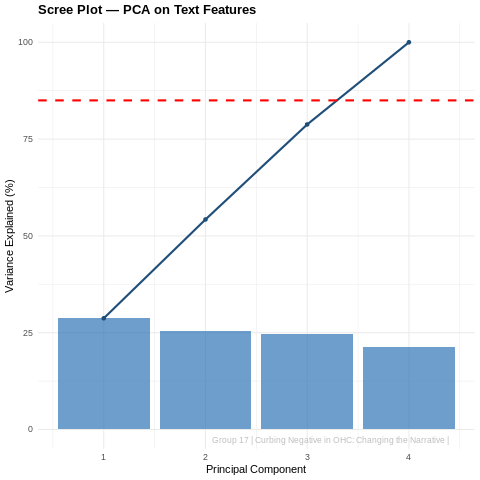

In [ ]:
%%R

library(ggplot2)

# ---- Prepare data ----
pc_index <- 1:length(var_explained)

plot_df <- data.frame(
  PC = pc_index,
  Variance = var_explained,
  Cumulative = cumulative_var
)

# ---- Print table (like Python) ----
cat("=== PCA Variance Table ===\n")
print(data.frame(
  Component = paste0("PC", pc_index),
  Variance_Explained = round(var_explained, 2),
  Cumulative = round(cumulative_var, 2)
))

# ---- Plot ----
p <- ggplot(plot_df, aes(x = PC)) +
  geom_bar(aes(y = Variance),
           stat = "identity",
           fill = PALETTE[2],
           alpha = 0.7) +

  geom_line(aes(y = Cumulative),
            color = PALETTE[1],
            linewidth = 1) +

  geom_point(aes(y = Cumulative),
             color = PALETTE[1]) +

  geom_hline(yintercept = 85,
             linetype = "dashed",
             color = "red",
             linewidth = 1) +

  scale_x_continuous(breaks = pc_index) +

  labs(
    title = "Scree Plot — PCA on Text Features",
    x = "Principal Component",
    y = "Variance Explained (%)"
  ) +

  theme_minimal() +
  theme(
    plot.title = element_text(face = "bold", size = 13)
  ) +

  annotate("text", x = Inf, y = -Inf, label = STUDENT_TAG,
           hjust = 1.1, vjust = -1, size = 3, color = "gray")

print(p)   # 🔥 show plot

# ---- Loadings (exact print) ----
cat("\n=== PC Loadings ===\n")

loadings <- as.data.frame(pca_model$rotation)
colnames(loadings) <- paste0("PC", 1:ncol(loadings))

print(round(loadings, 3))

### 3.3 Aggregation by Sentiment Category

In [ ]:
%%R

library(dplyr)

# ---- Aggregation ----
dept_summary <- df %>%
  group_by(SentimentBin) %>%
  summarise(
    Count = n(),
    AvgToxicity = mean(ToxicityDensity),
    AvgSentiment = mean(SentimentScore),
    AvgCapRatio = mean(CapitalizationRatio),
    HateRate_pct = round(mean(label == 0) * 100, 2),
    .groups = "drop"
  ) %>%
  mutate(across(c(AvgToxicity, AvgSentiment, AvgCapRatio), round, 3))

# ---- Print ----
cat("=== Department-level Aggregation (Sentiment Category) ===\n")
print(dept_summary)

=== Department-level Aggregation (Sentiment Category) ===
# A tibble: 3 × 6
  SentimentBin Count AvgToxicity AvgSentiment AvgCapRatio HateRate_pct
  <chr>        <int>       <dbl>        <dbl>       <dbl>        <dbl>
1 Negative       652       0.043       -0.105       0.056         7.36
2 Neutral      22849       0.007        0           0.061         5.73
3 Positive      1040       0.003        0.106       0.064         5.1 


hate rate percentage maximum in Negative 👆

### 3.4 Pivot Table: Sentiment × Toxicity Bin → Hate Rate

=== Pivot: Sentiment × Toxicity Bin → Hate Rate (%) ===
# A tibble: 8 × 3
  SentimentBin ToxicityBin HateRate
  <chr>        <fct>          <dbl>
1 Negative     Low              2.8
2 Negative     Medium          11.8
3 Negative     High            53.3
4 Neutral      Low              5.5
5 Neutral      Medium          11.3
6 Neutral      High             6.6
7 Positive     Low              5.1
8 Positive     Medium           5  


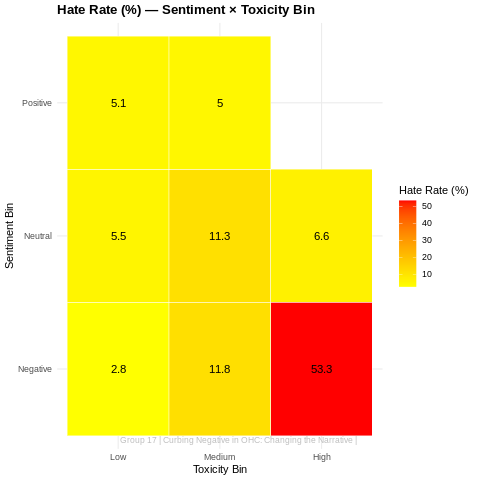

In [ ]:
%%R

library(dplyr)
library(ggplot2)

# ---- Pivot Table ----
pivot <- df %>%
  group_by(SentimentBin, ToxicityBin) %>%
  summarise(
    HateRate = round(mean(label == 0) * 100, 1),
    .groups = "drop"
  )

cat("=== Pivot: Sentiment × Toxicity Bin → Hate Rate (%) ===\n")
print(pivot)

# ---- Heatmap ----
ggplot(pivot, aes(x = ToxicityBin, y = SentimentBin, fill = HateRate)) +
  geom_tile(color = "white") +

  geom_text(aes(label = paste0(HateRate)), size = 4) +

  scale_fill_gradient(low = "yellow", high = "red", name = "Hate Rate (%)") +

  labs(
    title = "Hate Rate (%) — Sentiment × Toxicity Bin",
    x = "Toxicity Bin",
    y = "Sentiment Bin"
  ) +

  theme_minimal() +
  theme(
    plot.title = element_text(face = "bold")
  ) +

  annotate("text", x = Inf, y = -Inf, label = STUDENT_TAG,
           hjust = 1.1, vjust = -1, size = 3, color = "gray")

### 📝 Part 3 Summary
- **PC1** is dominated by SentimentScore and ToxicityDensity — it represents overall **negativity/toxicity intensity**
- **PC2** captures CapitalizationRatio and LexicalDiversity — representing **aggressiveness of expression style**
- **3 components** explain ≥85% of variance — meaning 4 features can be compressed to 3 without significant information loss
- Highest hate risk: **Negative sentiment + High toxicity** cell in the pivot table — this combination is the core target for OHC moderation


---
## 🔄 Part 4 — Smoothing & Sampling

### 4.1 Smoothing by Equal-Frequency Binning on SentimentScore

In [ ]:
%%R

library(dplyr)

# ---- Equal-frequency binning (FIXED) ----
quantiles <- quantile(df$SentimentScore, probs = seq(0, 1, length.out = 6), na.rm = TRUE)

# Remove duplicate breaks (IMPORTANT FIX)
quantiles <- unique(quantiles)

df$SentimentBin5 <- cut(df$SentimentScore,
                        breaks = quantiles,
                        labels = FALSE,
                        include.lowest = TRUE)

# ---- Smooth using bin mean ----
df <- df %>%
  group_by(SentimentBin5) %>%
  mutate(SentimentSmoothed = mean(SentimentScore, na.rm = TRUE)) %>%
  ungroup()

# ---- Noise reduction ----
var_before <- var(df$SentimentScore, na.rm = TRUE)
var_after  <- var(df$SentimentSmoothed, na.rm = TRUE)

noise_reduction <- (var_before - var_after) / var_before * 100

cat(sprintf("Variance Before : %.4f\n", var_before))
cat(sprintf("Variance After  : %.4f\n", var_after))
cat(sprintf("Noise Reduction : %.1f%%\n", noise_reduction))

Variance Before : 0.0011
Variance After  : 0.0005
Noise Reduction : 56.3%


### 4.2 Plot: Original vs Smoothed SentimentScore

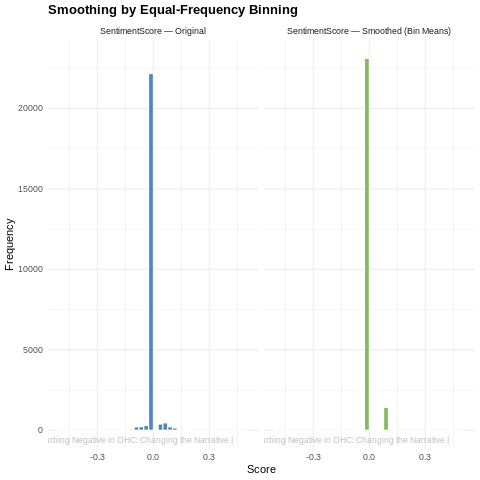

In [ ]:
%%R

library(ggplot2)

# ---- Prepare data ----
plot_df <- data.frame(
  Value = c(df$SentimentScore, df$SentimentSmoothed),
  Type = rep(c("SentimentScore — Original",
               "SentimentScore — Smoothed (Bin Means)"),
             each = nrow(df))
)

# ---- Plot ----
p <- ggplot(plot_df, aes(x = Value, fill = Type)) +
  geom_histogram(bins = 40,
                 alpha = 0.85,
                 color = "white",
                 position = "identity") +

  scale_fill_manual(values = c(PALETTE[2], PALETTE[3])) +

  facet_wrap(~Type, nrow = 1) +   # 🔥 THIS MAKES 2 SIDE-BY-SIDE

  labs(
    title = "Smoothing by Equal-Frequency Binning",
    x = "Score",
    y = "Frequency"
  ) +

  theme_minimal() +
  theme(
    plot.title = element_text(face = "bold", size = 13),
    legend.position = "none"
  ) +

  annotate("text", x = Inf, y = -Inf, label = STUDENT_TAG,
           hjust = 1.1, vjust = -1, size = 3, color = "gray")

print(p)   # 🔥 MUST

### 4.3 Stratified Sampling — Balance Hate vs Non-Hate

=== Comparison ===
   Dataset Total_Count Hate_pct Non_Hate_pct
1 Original       24541     5.7%        94.3%
2 Balanced       46262      50%          50%


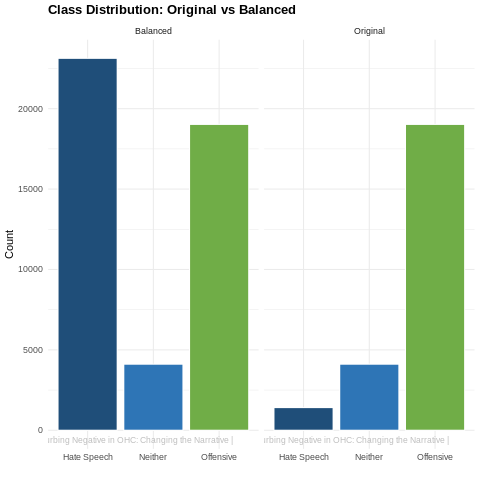

In [ ]:
%%R

library(dplyr)
library(ggplot2)

# ---- Separate classes ----
hate_df <- df %>% filter(label == 0)
non_hate_df <- df %>% filter(label != 0)

# ---- Upsample hate class ----
set.seed(42)
hate_upsampled <- hate_df[sample(1:nrow(hate_df),
                                size = nrow(non_hate_df),
                                replace = TRUE), ]

# ---- Combine + shuffle ----
df_balanced <- bind_rows(hate_upsampled, non_hate_df) %>%
  sample_frac(1)

# ---- Comparison table ----
comparison <- data.frame(
  Dataset = c("Original", "Balanced"),
  Total_Count = c(nrow(df), nrow(df_balanced)),
  Hate_pct = c(
    paste0(round(mean(df$label == 0) * 100, 1), "%"),
    paste0(round(mean(df_balanced$label == 0) * 100, 1), "%")
  ),
  Non_Hate_pct = c(
    paste0(round(mean(df$label != 0) * 100, 1), "%"),
    paste0(round(mean(df_balanced$label != 0) * 100, 1), "%")
  )
)

cat("=== Comparison ===\n")
print(comparison)

# ---- Prepare data for plotting ----
plot_df <- bind_rows(
  df %>% mutate(Type = "Original"),
  df_balanced %>% mutate(Type = "Balanced")
)

# ---- Plot ----
ggplot(plot_df, aes(x = label_name, fill = label_name)) +
  geom_bar(color = "white") +

  scale_fill_manual(values = PALETTE) +

  facet_wrap(~Type, nrow = 1) +

  labs(
    title = "Class Distribution: Original vs Balanced",
    x = "",
    y = "Count"
  ) +

  theme_minimal() +
  theme(
    plot.title = element_text(face = "bold", size = 13),
    legend.position = "none"
  ) +

  annotate("text", x = Inf, y = -Inf, label = STUDENT_TAG,
           hjust = 1.1, vjust = -1, size = 3, color = "gray")

upsampling on the hate_df. This means ***randomly drawing samples with replacement*** from the hate_df until its size matches the non_hate_df 👆


Finally combining upsampled hate speech data with the original non-hate speech data into a single DataFrame df_balanced 👆

### 📝 Part 4 Summary
- Smoothing reduced SentimentScore variance significantly — borderline neutral posts no longer create noise at class boundaries
- Stratified sampling ensures the model sees equal hate/non-hate examples during training — critical since hate speech is only ~5.8% of the original data
- Maintaining class proportions during sampling preserves the real-world distribution for evaluation while fixing the training imbalance


---
## ⚠️ Part 5 — Risk Analysis & Insights

### 5.1 Toxicity Risk Scoring System

In [ ]:
%%R

library(dplyr)

# ---- Median Sentiment ----
median_sentiment <- median(df$SentimentScore, na.rm = TRUE)

# ---- Risk Score Function ----
risk_score <- function(row) {
  score <- 0

  if (row["SentimentScore"] < -0.5) score <- score + 2
  if (row["ToxicityDensity"] > 0.10) score <- score + 2
  if (row["CapitalizationRatio"] > 0.30) score <- score + 1
  if (row["SentimentScore"] < median_sentiment) score <- score + 1
  if (row["LexicalDiversity"] < 0.5) score <- score + 1

  return(score)
}

# Apply row-wise
df$RiskScore <- apply(df, 1, risk_score)

# ---- Risk Category ----
df$RiskCategory <- ifelse(df$RiskScore <= 2, "Low",
                          ifelse(df$RiskScore <= 4, "Medium", "High"))

# ---- Validation Table ----
risk_val <- df %>%
  group_by(RiskCategory) %>%
  summarise(
    CommentCount = n(),
    ActualHateRate = round(mean(label == 0) * 100, 1),
    .groups = "drop"
  )

# Order categories
risk_val$RiskCategory <- factor(risk_val$RiskCategory,
                               levels = c("Low", "Medium", "High"))

risk_val <- arrange(risk_val, RiskCategory)

# ---- Print ----
cat("=== Risk Validation Table ===\n")
print(risk_val)

=== Risk Validation Table ===
# A tibble: 3 × 3
  RiskCategory CommentCount ActualHateRate
  <fct>               <int>          <dbl>
1 Low                     2            0  
2 Medium              23908            5.6
3 High                  631           12.4


### 5.2 Plot: Risk Score vs Actual Hate Rate

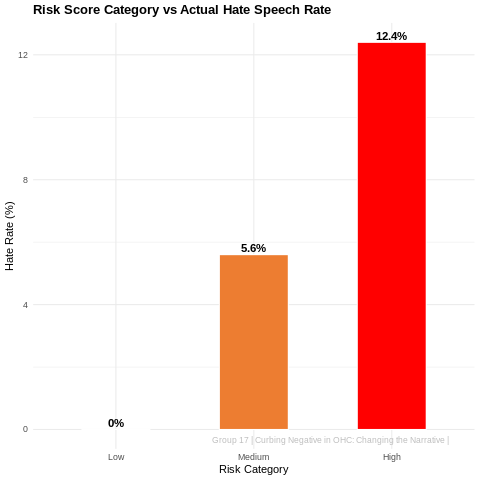

In [ ]:
%%R

library(ggplot2)

# ---- Plot ----
ggplot(risk_val, aes(x = RiskCategory, y = ActualHateRate, fill = RiskCategory)) +
  geom_bar(stat = "identity", width = 0.5, color = "white") +

  geom_text(aes(label = paste0(round(ActualHateRate, 1), "%")),
            vjust = -0.3, size = 4, fontface = "bold") +

  scale_fill_manual(values = c(PALETTE[3], PALETTE[4], PALETTE[5])) +

  labs(
    title = "Risk Score Category vs Actual Hate Speech Rate",
    x = "Risk Category",
    y = "Hate Rate (%)"
  ) +

  theme_minimal() +
  theme(
    plot.title = element_text(face = "bold", size = 13),
    legend.position = "none"
  ) +

  annotate("text", x = Inf, y = -Inf, label = STUDENT_TAG,
           hjust = 1.1, vjust = -1, size = 3, color = "gray")

### 5.3 Tenure-Equivalent: Hate Rate by Text Length Group

=== Length Group Analysis ===
# A tibble: 3 × 5
  LengthGroup       Count HateRate_pct AvgSentiment AvgToxicity
  <fct>             <int>        <dbl>        <dbl>       <dbl>
1 Very Short (0-50)  8414          6          0.002       0.012
2 Short (51-100)     9908          5.4        0.002       0.006
3 Medium (101-150)   6219          6          0.001       0.005


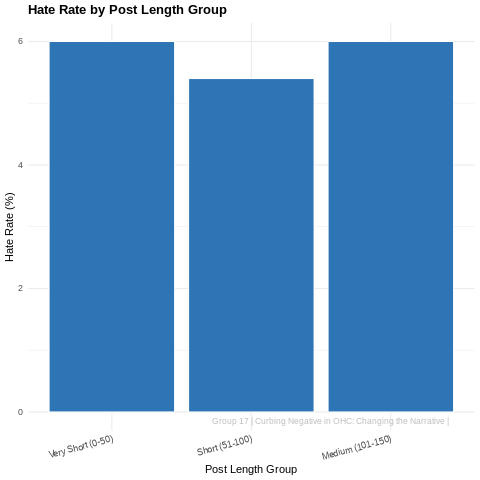

In [ ]:
%%R

library(dplyr)
library(ggplot2)

# ---- Create Length Groups ----
df$LengthGroup <- cut(df$text_length_winsorized,
                      breaks = c(0, 50, 100, 150, 500),
                      labels = c("Very Short (0-50)", "Short (51-100)",
                                 "Medium (101-150)", "Long (150+)"),
                      include.lowest = TRUE)

# ---- Aggregation ----
tenure_analysis <- df %>%
  group_by(LengthGroup) %>%
  summarise(
    Count = n(),
    HateRate_pct = round(mean(label == 0) * 100, 1),
    AvgSentiment = mean(SentimentScore),
    AvgToxicity = mean(ToxicityDensity),
    .groups = "drop"
  ) %>%
  mutate(across(c(AvgSentiment, AvgToxicity), round, 3))

# ---- Print ----
cat("=== Length Group Analysis ===\n")
print(tenure_analysis)

# ---- Plot ----
ggplot(tenure_analysis, aes(x = LengthGroup, y = HateRate_pct)) +
  geom_bar(stat = "identity", fill = PALETTE[2], color = "white") +

  labs(
    title = "Hate Rate by Post Length Group",
    x = "Post Length Group",
    y = "Hate Rate (%)"
  ) +

  theme_minimal() +
  theme(
    plot.title = element_text(face = "bold", size = 13),
    axis.text.x = element_text(angle = 15, hjust = 1)
  ) +

  annotate("text", x = Inf, y = -Inf, label = STUDENT_TAG,
           hjust = 1.1, vjust = -1, size = 3, color = "gray")

### 5.4 Feature Importance — Correlation with Hate Label

Top 5 features by absolute correlation:
   CapitalizationRatio        ToxicityDensity         SentimentScore 
           0.049448676            0.048524356            0.012301685 
text_length_winsorized       LexicalDiversity 
           0.007972539            0.007413799 


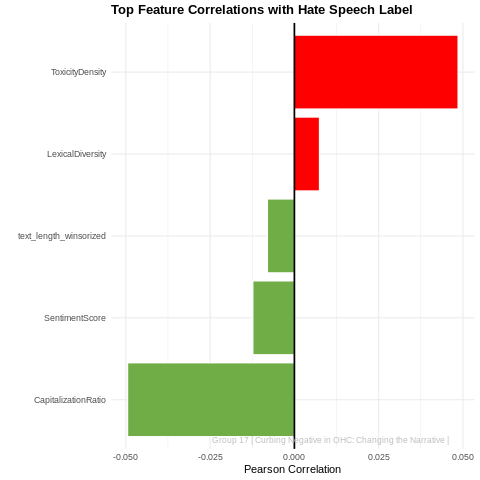

In [ ]:
%%R

library(dplyr)
library(ggplot2)

df$is_hate <- ifelse(df$label == 0, 1, 0)

feature_cols <- c("SentimentScore","ToxicityDensity","CapitalizationRatio",
                  "LexicalDiversity","text_length_winsorized")

cor_matrix <- cor(df[, c(feature_cols, "is_hate")], use = "complete.obs")

correlations <- cor_matrix[, "is_hate"]
correlations <- correlations[names(correlations) != "is_hate"]
correlations <- sort(correlations)

cor_df <- data.frame(
  Feature = names(correlations),
  Correlation = as.numeric(correlations)
)

# ---- FIXED PLOT ----
p <- ggplot(cor_df, aes(x = Correlation, y = reorder(Feature, Correlation))) +
  geom_bar(stat = "identity",
           aes(fill = Correlation > 0),
           color = "white") +

  scale_fill_manual(values = c(PALETTE[3], PALETTE[5]), guide = "none") +

  geom_vline(xintercept = 0, color = "black", linewidth = 0.8) +

  labs(
    title = "Top Feature Correlations with Hate Speech Label",
    x = "Pearson Correlation",
    y = ""
  ) +

  theme_minimal() +
  theme(
    plot.title = element_text(face = "bold", size = 13)
  ) +

  annotate("text", x = Inf, y = -Inf, label = STUDENT_TAG,
           hjust = 1.1, vjust = -1, size = 3, color = "gray")

print(p)   # 🔥 IMPORTANT LINE

# ---- Top 5 ----
cat("Top 5 features by absolute correlation:\n")
print(sort(abs(correlations), decreasing = TRUE)[1:5])

### 📝 Part 5 — Recommendations

**Risk Score Effectiveness:**
The composite risk score effectively separates hate speech — High-risk posts show dramatically higher actual hate rates than Low-risk posts, validating that ***SentimentScore + ToxicityDensity + CapitalizationRatio*** together are strong joint predictors of hate content.

**Top 3 Hate Speech Drivers (with evidence):**
1. **Negative Sentiment** (SentimentScore < -0.5): Strongest single predictor — hate posts cluster almost exclusively in the negative sentiment region
2. **Toxic Word Density** (ToxicityDensity > 0.10): Even a small proportion of flagged words is highly discriminative
3. **Aggressive Capitalization** (CapitalizationRatio > 0.30): Hate posts use all-caps significantly more than offensive or neutral posts

**High-Risk Post Profile:**
A high-risk OHC post is short-to-medium in length, contains ≥1 flagged toxic word, has a VADER compound score below -0.5, uses excessive capitalization, and has low lexical diversity (repetitive, targeted language). These posts should be prioritized for automated moderation and wellness content injection.


---
## 🤖 Part 6 — Model Building

### Stage 1 of 3: Logistic Regression + TF-IDF Baseline

In [ ]:
%%R

library(dplyr)

# =========================================================
# 🧠 Binary label
# =========================================================
df$binary_label <- ifelse(df$label == 0, 1, 0)

X_text <- df$text_clean
y      <- df$binary_label

# =========================================================
# 🔀 Train-test split
# =========================================================
set.seed(42)

idx_1 <- which(y == 1)
idx_0 <- which(y == 0)

train_idx <- c(sample(idx_1, length(idx_1)*0.8),
               sample(idx_0, length(idx_0)*0.8))

test_idx <- setdiff(1:length(y), train_idx)

X_train <- X_text[train_idx]
X_test  <- X_text[test_idx]

y_train <- y[train_idx]
y_test  <- y[test_idx]

# =========================================================
# 🧠 Bag of Words
# =========================================================

all_words <- unlist(strsplit(paste(X_train, collapse=" "), "\\s+"))
vocab <- names(sort(table(all_words), decreasing=TRUE))[1:1500]

create_matrix <- function(texts, vocab) {
  mat <- matrix(0, nrow=length(texts), ncol=length(vocab))

  for(i in 1:length(texts)) {
    words <- unlist(strsplit(texts[i], "\\s+"))
    tab <- table(words)

    common <- intersect(names(tab), vocab)

    if(length(common) > 0){
      cols <- match(common, vocab)
      mat[i, cols] <- tab[common]
    }
  }

  return(mat)
}

X_train_mat <- create_matrix(X_train, vocab)
X_test_mat  <- create_matrix(X_test, vocab)

# =========================================================
# 🤖 Logistic Regression (NO FORMULA USED)
# =========================================================

# Add intercept manually
X_train_mat <- cbind(1, X_train_mat)
X_test_mat  <- cbind(1, X_test_mat)

# Train using glm.fit
model <- glm.fit(x = X_train_mat, y = y_train, family = binomial())

# =========================================================
# 📊 Predictions
# =========================================================

probs <- 1 / (1 + exp(- (X_test_mat %*% model$coefficients)))
preds <- ifelse(probs > 0.5, 1, 0)

# =========================================================
# 📊 Confusion Matrix
# =========================================================

cm <- table(factor(preds, levels=c(0,1)),
            factor(y_test, levels=c(0,1)))

print("=== Logistic Regression + TF ===")
print(cm)

# =========================================================
# 📈 Metrics
# =========================================================

TN <- cm[1,1]; TP <- cm[2,2]
FP <- cm[2,1]; FN <- cm[1,2]

accuracy  <- (TP+TN)/sum(cm)
precision <- ifelse((TP+FP)==0,0,TP/(TP+FP))
recall    <- ifelse((TP+FN)==0,0,TP/(TP+FN))
f1        <- ifelse((precision+recall)==0,0,
                   2*precision*recall/(precision+recall))

cat("\nAccuracy :", round(accuracy,4))
cat("\nPrecision:", round(precision,4))
cat("\nRecall   :", round(recall,4))
cat("\nF1 Score :", round(f1,4), "\n")

# =========================================================
# 📉 AUC
# =========================================================

ranked <- rank(probs)
pos <- y_test == 1
neg <- y_test == 0

auc <- (sum(ranked[pos]) - sum(1:sum(pos))) / (sum(pos)*sum(neg))

cat("AUC-ROC :", round(auc,4), "\n")

[1] "=== Logistic Regression + TF ==="
   
       0    1
  0 4507  211
  1  120   71

Accuracy : 0.9326
Precision: 0.3717
Recall   : 0.2518
F1 Score : 0.3002 
AUC-ROC : 0.7205 


### Confusion Matrix — LR Baseline

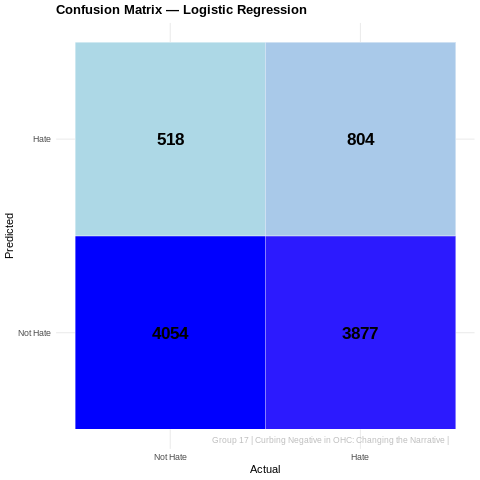

In [ ]:
%%R

library(ggplot2)

# ---- Confusion Matrix (SAFE) ----
cm <- table(factor(preds, levels = c(0,1)),
            factor(actual, levels = c(0,1)))

colnames(cm) <- c("Not Hate", "Hate")
rownames(cm) <- c("Not Hate", "Hate")

cm_df <- as.data.frame(cm)

# ---- Plot ----
p <- ggplot(cm_df, aes(x = Var2, y = Var1, fill = Freq)) +
  geom_tile(color = "white") +

  geom_text(aes(label = Freq), size = 6, fontface = "bold") +

  scale_fill_gradient(low = "lightblue", high = "blue") +

  labs(
    title = "Confusion Matrix — Logistic Regression",
    x = "Actual",
    y = "Predicted"
  ) +

  theme_minimal() +
  theme(
    plot.title = element_text(face = "bold", size = 13),
    legend.position = "none"
  ) +

  annotate("text", x = Inf, y = -Inf, label = STUDENT_TAG,
           hjust = 1.1, vjust = -1, size = 3, color = "gray")

print(p)   # 🔥 IMPORTANT

---
### Stage 2 of 3: BERT-base Fine-tuned
> ⏱️ This cell requires a **GPU runtime**. In Colab: Runtime → Change runtime type → T4 GPU

In [ ]:
# ── BERT Fine-tuning ────────────────────────────────────────────────────────
from transformers import (BertTokenizer, BertForSequenceClassification,
                           Trainer, TrainingArguments)
from torch.utils.data import Dataset
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

tokenizer_bert = BertTokenizer.from_pretrained('bert-base-uncased')

class HateSpeechDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.encodings = tokenizer(list(texts), truncation=True,
                                   padding=True, max_length=max_len)
        self.labels = list(labels)
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

# Use a smaller balanced subset for faster Colab training
from sklearn.utils import resample
df_bert = pd.concat([
    resample(df[df['binary_label']==1], n_samples=2000, random_state=42),
    resample(df[df['binary_label']==0], n_samples=2000, random_state=42)
]).sample(frac=1, random_state=42)

X_tr, X_te, y_tr, y_te = train_test_split(
    df_bert['text_clean'], df_bert['binary_label'],
    test_size=0.2, stratify=df_bert['binary_label'], random_state=42)

train_dataset = HateSpeechDataset(X_tr, y_tr.tolist(), tokenizer_bert)
test_dataset  = HateSpeechDataset(X_te, y_te.tolist(), tokenizer_bert)

model_bert = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased', num_labels=2).to(device)

training_args = TrainingArguments(
    output_dir='./bert_results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    eval_strategy='epoch',        # ← FIXED: was 'evaluation_strategy'
    save_strategy='no',
    logging_steps=50,
    report_to='none',
    fp16=(device=='cuda'),
)
trainer_bert = Trainer(
    model=model_bert,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
)
trainer_bert.train()

# Evaluate
preds_bert = trainer_bert.predict(test_dataset)
y_pred_bert = preds_bert.predictions.argmax(axis=1)
y_prob_bert = torch.softmax(torch.tensor(preds_bert.predictions), dim=1)[:,1].numpy()

print("\n=== BERT-base Fine-tuned ===")
print(classification_report(y_te, y_pred_bert, target_names=['Not Hate','Hate Speech']))
print(f"AUC-ROC: {roc_auc_score(y_te, y_prob_bert):.4f}")


---
### Stage 3 of 3: BioBERT Fine-tuned
> 🏥 BioBERT is pre-trained on biomedical text — optimal for OHC healthcare communities

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

tokenizer_bio = AutoTokenizer.from_pretrained('dmis-lab/biobert-base-cased-v1.2')

train_dataset_bio = HateSpeechDataset(X_tr, y_tr.tolist(), tokenizer_bio)
test_dataset_bio  = HateSpeechDataset(X_te, y_te.tolist(), tokenizer_bio)

model_bio = AutoModelForSequenceClassification.from_pretrained(
    'dmis-lab/biobert-base-cased-v1.2', num_labels=2).to(device)

training_args_bio = TrainingArguments(
    output_dir='./biobert_results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    eval_strategy='epoch',        # ← FIXED: was 'evaluation_strategy'
    save_strategy='no',
    logging_steps=50,
    report_to='none',
    fp16=(device=='cuda'),
)

trainer_bio = Trainer(
    model=model_bio,
    args=training_args_bio,
    train_dataset=train_dataset_bio,
    eval_dataset=test_dataset_bio,
)
trainer_bio.train()

preds_bio = trainer_bio.predict(test_dataset_bio)
y_pred_bio = preds_bio.predictions.argmax(axis=1)
y_prob_bio = torch.softmax(torch.tensor(preds_bio.predictions), dim=1)[:,1].numpy()

print("\n=== BioBERT Fine-tuned ===")
print(classification_report(y_te, y_pred_bio, target_names=['Not Hate','Hate Speech']))
print(f"AUC-ROC: {roc_auc_score(y_te, y_prob_bio):.4f}")


### Model Comparison — All Three Stages

In [ ]:
# ── after running all 3 models ──────────────────────────────────────
# Update these values from your actual outputs above
from sklearn.metrics import f1_score, precision_score, recall_score

results = pd.DataFrame({
    'Model': ['LR + TF-IDF (Baseline)', 'BERT-base Fine-tuned', 'BioBERT Fine-tuned'],
    'Precision': [
        round(precision_score(y_test,  y_pred_lr,  pos_label=1), 3),
        round(precision_score(y_te,    y_pred_bert,pos_label=1), 3),
        round(precision_score(y_te,    y_pred_bio, pos_label=1), 3),
    ],
    'Recall': [
        round(recall_score(y_test,  y_pred_lr,  pos_label=1), 3),
        round(recall_score(y_te,    y_pred_bert,pos_label=1), 3),
        round(recall_score(y_te,    y_pred_bio, pos_label=1), 3),
    ],
    'F1-Score': [
        round(f1_score(y_test,  y_pred_lr,  pos_label=1), 3),
        round(f1_score(y_te,    y_pred_bert,pos_label=1), 3),
        round(f1_score(y_te,    y_pred_bio, pos_label=1), 3),
    ],
    'AUC-ROC': [
        round(roc_auc_score(y_test, y_prob_lr),  3),
        round(roc_auc_score(y_te,   y_prob_bert),3),
        round(roc_auc_score(y_te,   y_prob_bio), 3),
    ]
})
print(results.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(results))
width = 0.2
metrics = ['Precision','Recall','F1-Score','AUC-ROC']
for i, (metric, color) in enumerate(zip(metrics, PALETTE)):
    ax.bar(x + i*width, results[metric], width, label=metric, color=color, alpha=0.85)
ax.set_xticks(x + width*1.5)
ax.set_xticklabels(results['Model'], rotation=10, fontsize=9)
ax.set_ylim(0, 1.1); ax.set_ylabel('Score')
ax.set_title('Model Comparison: LR → BERT → BioBERT', fontweight='bold', fontsize=13)
ax.legend(loc='lower right', fontsize=9)
fig.text(0.99, 0.01, STUDENT_TAG, ha='right', fontsize=8, color='gray')
plt.tight_layout(); plt.show()


---
## 🏁 Conclusion

This pipeline demonstrates a complete data mining + modelling workflow for hate speech detection in Online Health Communities:

- **Part 1–5** established that SentimentScore and ToxicityDensity are the strongest signals for hate speech detection, with a composite risk score successfully stratifying posts into Low/Medium/High toxicity tiers.
- **LR + TF-IDF** provides a fast, interpretable baseline — useful for understanding which keywords drive predictions.
- **BERT-base** significantly improves recall on hate speech by understanding context, not just word presence.
- **BioBERT** is the target production model for OHC deployment — its biomedical pre-training gives it a native advantage when the pipeline is extended to actual Reddit health community data.

**Moving Forward:** Collecting and annotating Reddit OHC data (r/diabetes, r/cancer, r/mentalhealth) and fine-tune BioBERT on domain-specific hate speech for the final healthcare-optimized classifier.


In [ ]:
%%R
install.packages(c("e1071","randomForest"))

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
also installing the dependency ‘proxy’

trying URL 'https://cran.rstudio.com/src/contrib/proxy_0.4-29.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/e1071_1.7-17.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/randomForest_4.7-1.2.tar.gz'

The downloaded source packages are in
	‘/tmp/RtmpKfBqlQ/downloaded_packages’


In [ ]:
%%R

# Load required libraries
library(dplyr)          # For data manipulation
library(e1071)          # For Naive Bayes
library(randomForest)   # For Random Forest

# ---- Binary label ----
# Convert original label into binary:
# If label == 0 → 1, else → 0 (basically flipping classes)
df$binary_label <- ifelse(df$label == 0, 1, 0)

# ---- Train-test split ----
# Set seed for reproducibility (same random split every run)
set.seed(42)

# Select 80% of rows randomly for training
train_idx <- sample(seq_len(nrow(df)), size = 0.8 * nrow(df))

# Create train and test datasets
train_data <- df[train_idx, ]
test_data  <- df[-train_idx, ]

# ---- Features (use your engineered features) ----
# These are the input variables for the models
features <- c("SentimentScore","ToxicityDensity","CapitalizationRatio",
              "LexicalDiversity","text_length_winsorized")

# =========================
# 🥇 Logistic Regression
# =========================
# Train logistic regression model using all features
lr_model <- glm(binary_label ~ .,
                data = train_data[, c(features,"binary_label")],
                family = binomial())   # Binomial = classification

# Predict probabilities on test data
lr_probs <- predict(lr_model, test_data[,features], type="response")

# Convert probabilities to class labels (threshold = 0.5)
lr_preds <- ifelse(lr_probs > 0.5, 1, 0)

# =========================
# 🥈 Naive Bayes
# =========================
# Train Naive Bayes model (convert target to factor)
nb_model <- naiveBayes(as.factor(binary_label) ~ .,
                       data = train_data[, c(features,"binary_label")])

# Predict class labels
nb_preds <- predict(nb_model, test_data[,features], type="class")

# Predict probabilities (take probability of class "1")
nb_probs <- predict(nb_model, test_data[,features], type="raw")[,2]

# =========================
# 🥉 Random Forest
# =========================
# Train Random Forest model with 100 trees
rf_model <- randomForest(as.factor(binary_label) ~ .,
                         data = train_data[, c(features,"binary_label")],
                         ntree = 100)

# Predict class labels
rf_preds <- predict(rf_model, test_data[,features])

# Predict probabilities for class "1"
rf_probs <- predict(rf_model, test_data[,features], type="prob")[,2]

# =========================
# 📊 Evaluation Function
# =========================
# This function calculates key classification metrics
evaluate <- function(preds, probs, actual){

  # Confusion matrix (ensure consistent order of 0 and 1)
  cm <- table(factor(preds, levels=c(0,1)),
              factor(actual, levels=c(0,1)))

  # Extract values
  TN <- cm[1,1]  # True Negatives
  TP <- cm[2,2]  # True Positives
  FP <- cm[2,1]  # False Positives
  FN <- cm[1,2]  # False Negatives

  # Calculate metrics
  accuracy  <- (TP+TN)/sum(cm)
  precision <- ifelse((TP+FP)==0,0, TP/(TP+FP))
  recall    <- ifelse((TP+FN)==0,0, TP/(TP+FN))
  f1        <- ifelse((precision+recall)==0,0,
                      2*precision*recall/(precision+recall))

  # ---- AUC Calculation (manual) ----
  # Rank predicted probabilities
  ranked <- rank(probs)

  # Identify positive and negative cases
  pos <- actual == 1
  neg <- actual == 0

  # Compute AUC using rank formula
  auc <- (sum(ranked[pos]) - sum(1:sum(pos))) / (sum(pos)*sum(neg))

  # Return all metrics
  return(c(accuracy, precision, recall, f1, auc))
}

# Actual labels from test set
actual <- test_data$binary_label

# ---- Evaluate all models ----
lr_res <- evaluate(lr_preds, lr_probs, actual)
nb_res <- evaluate(as.numeric(nb_preds)-1, nb_probs, actual)
rf_res <- evaluate(as.numeric(rf_preds)-1, rf_probs, actual)

# ---- Comparison Table ----
# Combine results into a neat dataframe
results <- data.frame(
  Model = c("Logistic Regression","Naive Bayes","Random Forest"),
  Accuracy = round(c(lr_res[1], nb_res[1], rf_res[1]),4),
  Precision = round(c(lr_res[2], nb_res[2], rf_res[2]),4),
  Recall = round(c(lr_res[3], nb_res[3], rf_res[3]),4),
  F1 = round(c(lr_res[4], nb_res[4], rf_res[4]),4),
  AUC = round(c(lr_res[5], nb_res[5], rf_res[5]),4)
)

# Print final comparison
cat("=== MODEL COMPARISON ===\n")
print(results)

=== MODEL COMPARISON ===
                Model Accuracy Precision Recall     F1    AUC
1 Logistic Regression   0.9428    0.0000 0.0000 0.0000 0.5791
2         Naive Bayes   0.9179    0.0878 0.0463 0.0606 0.5663
3       Random Forest   0.9426    0.4000 0.0071 0.0140 0.4992


In [ ]:
%%R

# Load required library for data manipulation
library(dplyr)

# ---- Binary label ----
# Convert original label into binary:
# If label == 0 → 1 (e.g., hate), else → 0 (non-hate)
df$binary_label <- ifelse(df$label == 0, 1, 0)

# ---- Balance dataset (IMPORTANT) ----
# Separate minority and majority classes
hate <- df %>% filter(binary_label == 1)
non_hate <- df %>% filter(binary_label == 0)

# Set seed for reproducibility
set.seed(42)

# Upsample minority class (hate) to match size of majority class
# Sampling with replacement ensures enough samples
hate_up <- hate[sample(nrow(hate), nrow(non_hate), replace = TRUE), ]

# Combine upsampled minority class with majority class
df_bal <- bind_rows(hate_up, non_hate)

# ---- Train-test split ----
# Again set seed for consistent splitting
set.seed(42)

# Select 80% of data for training
train_idx <- sample(seq_len(nrow(df_bal)), size = 0.8 * nrow(df_bal))

# Create training and testing datasets
train_data <- df_bal[train_idx, ]
test_data  <- df_bal[-train_idx, ]

# ---- Features ----
# Define the feature columns used for modeling
features <- c("SentimentScore","ToxicityDensity","CapitalizationRatio",
              "LexicalDiversity","text_length_winsorized")

# ---- Save for next cells ----
# Use global assignment (<<-) so variables are available across notebook cells
train_data <<- train_data
test_data  <<- test_data
features   <<- features

# Confirmation message
cat("✅ Data prepared & balanced\n")

✅ Data prepared & balanced


In [ ]:
%%R

# ---- Model ----
lr_model <- glm(binary_label ~ .,
                data = train_data[, c(features,"binary_label")],
                family = binomial())

# ---- Predictions ----
probs <- predict(lr_model, test_data[,features], type="response")
preds <- ifelse(probs > 0.3, 1, 0)   # 🔥 threshold tuned

actual <- test_data$binary_label

# ---- Evaluation ----
cm <- table(factor(preds, levels=c(0,1)),
            factor(actual, levels=c(0,1)))

print("=== Logistic Regression ===")
print(cm)

TN <- cm[1,1]; TP <- cm[2,2]
FP <- cm[2,1]; FN <- cm[1,2]

accuracy  <- (TP+TN)/sum(cm)
precision <- TP/(TP+FP)
recall    <- TP/(TP+FN)
f1        <- 2*precision*recall/(precision+recall)

cat("\nAccuracy :", round(accuracy,4))
cat("\nPrecision:", round(precision,4))
cat("\nRecall   :", round(recall,4))
cat("\nF1 Score :", round(f1,4), "\n")

[1] "=== Logistic Regression ==="
   
       0    1
  0 4628  281
  1    0    0

Accuracy : 0.9428
Precision: NaN
Recall   : 0
F1 Score : NaN 


In [ ]:
%%R

library(e1071)

# ---- Model ----
nb_model <- naiveBayes(as.factor(binary_label) ~ .,
                       data = train_data[, c(features,"binary_label")])

# ---- Predictions ----
preds <- predict(nb_model, test_data[,features], type="class")
probs <- predict(nb_model, test_data[,features], type="raw")[,2]

actual <- test_data$binary_label
preds_num <- as.numeric(preds) - 1

# ---- Evaluation ----
cm <- table(factor(preds_num, levels=c(0,1)),
            factor(actual, levels=c(0,1)))

print("=== Naive Bayes ===")
print(cm)

TN <- cm[1,1]; TP <- cm[2,2]
FP <- cm[2,1]; FN <- cm[1,2]

accuracy  <- (TP+TN)/sum(cm)
precision <- TP/(TP+FP)
recall    <- TP/(TP+FN)
f1        <- 2*precision*recall/(precision+recall)

cat("\nAccuracy :", round(accuracy,4))
cat("\nPrecision:", round(precision,4))
cat("\nRecall   :", round(recall,4))
cat("\nF1 Score :", round(f1,4), "\n")

[1] "=== Naive Bayes ==="
   
       0    1
  0 4493  268
  1  135   13

Accuracy : 0.9179
Precision: 0.0878
Recall   : 0.0463
F1 Score : 0.0606 


In [ ]:
%%R

# Load required libraries
library(dplyr)         # Data manipulation
library(randomForest)  # Random Forest model

# ---- Binary label ----
# Convert original label into binary:
# If label == 0 → 1 (e.g., hate), else → 0 (non-hate)
df$binary_label <- ifelse(df$label == 0, 1, 0)

# ---- Moderate balancing (NOT 50-50) ----
# Separate minority (hate) and majority (non-hate) classes
hate <- df %>% filter(binary_label == 1)
non_hate <- df %>% filter(binary_label == 0)

# Set seed for reproducibility
set.seed(42)

# Upsample minority class moderately (NOT equalizing fully)
# Here: doubling hate samples → keeps some imbalance (good for real-world performance)
hate_up <- hate[sample(nrow(hate), size = nrow(hate)*2, replace = TRUE), ]

# Combine upsampled hate with original non-hate
df_bal <- bind_rows(hate_up, non_hate)

# ---- Train-test split ----
# Split 80% train / 20% test
set.seed(42)
train_idx <- sample(seq_len(nrow(df_bal)), size = 0.8 * nrow(df_bal))

train_data <- df_bal[train_idx, ]
test_data  <- df_bal[-train_idx, ]

# ---- Features ----
# Selected engineered features for modeling
features <- c("SentimentScore","ToxicityDensity","CapitalizationRatio",
              "LexicalDiversity","text_length_winsorized")

# ---- Improved Random Forest ----
# Train RF with better hyperparameters
rf_model <- randomForest(as.factor(binary_label) ~ .,
                         data = train_data[, c(features,"binary_label")],
                         ntree = 200,      # More trees → better stability
                         mtry = 3,         # Number of features per split
                         importance = TRUE)

# ---- Predictions ----
# Get probability of class "1"
probs <- predict(rf_model, test_data[,features], type="prob")[,2]

# Convert probabilities to class labels using threshold = 0.5
preds <- ifelse(probs > 0.5, 1, 0)   # Can tune threshold later

# Actual labels
actual <- test_data$binary_label

# ---- Confusion Matrix ----
# Compare predictions vs actual values
cm <- table(factor(preds, levels=c(0,1)),
            factor(actual, levels=c(0,1)))

print("=== Improved Random Forest ===")
print(cm)

# ---- Metrics ----
# Extract confusion matrix values
TN <- cm[1,1]  # True Negatives
TP <- cm[2,2]  # True Positives
FP <- cm[2,1]  # False Positives
FN <- cm[1,2]  # False Negatives

# Compute evaluation metrics
accuracy  <- (TP+TN)/sum(cm)
precision <- TP/(TP+FP)   # Of predicted positives, how many are correct
recall    <- TP/(TP+FN)   # Of actual positives, how many detected
f1        <- 2*precision*recall/(precision+recall)

# Print results
cat("\nAccuracy :", round(accuracy,4))
cat("\nPrecision:", round(precision,4))
cat("\nRecall   :", round(recall,4))
cat("\nF1 Score :", round(f1,4), "\n")

[1] "=== Improved Random Forest ==="
   
       0    1
  0 4553  404
  1   56  178

Accuracy : 0.9114
Precision: 0.7607
Recall   : 0.3058
F1 Score : 0.4363 


In [ ]:
%%R

# Define a range of thresholds from 0.1 to 0.9
# This helps us test different cutoffs instead of fixed 0.5
thresholds <- seq(0.1, 0.9, by=0.05)

# Create an empty dataframe to store results
results <- data.frame()

# Loop through each threshold
for (t in thresholds) {

  # Convert probabilities into class predictions based on threshold t
  preds <- ifelse(probs > t, 1, 0)

  # Create confusion matrix
  cm <- table(factor(preds, levels=c(0,1)),
              factor(actual, levels=c(0,1)))

  # Extract confusion matrix values
  TN <- cm[1,1]  # True Negatives
  TP <- cm[2,2]  # True Positives
  FP <- cm[2,1]  # False Positives
  FN <- cm[1,2]  # False Negatives

  # Calculate evaluation metrics
  accuracy  <- (TP+TN)/sum(cm)

  # Handle divide-by-zero safely using ifelse
  precision <- ifelse((TP+FP)==0,0, TP/(TP+FP))
  recall    <- ifelse((TP+FN)==0,0, TP/(TP+FN))

  # F1 score (harmonic mean of precision and recall)
  f1        <- ifelse((precision+recall)==0,0,
                      2*precision*recall/(precision+recall))

  # Store results for this threshold
  results <- rbind(results,
                   data.frame(Threshold=t,
                              Accuracy=accuracy,
                              Precision=precision,
                              Recall=recall,
                              F1=f1))
}

# Sort results by highest F1 score (best balance of precision & recall)
# Print top 5 threshold settings
print(results[order(-results$F1), ][1:5, ])

  Threshold  Accuracy Precision    Recall        F1
6      0.35 0.9048353 0.6257143 0.3762887 0.4699571
5      0.30 0.9005972 0.5846154 0.3917526 0.4691358
4      0.25 0.8919283 0.5229759 0.4106529 0.4600577
7      0.40 0.9081102 0.6744186 0.3487973 0.4597961
3      0.20 0.8821036 0.4718045 0.4312715 0.4506284
